In [ ]:
# libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as plt

In [33]:
# loading dataset
df = pd.read_csv("/content/drive/MyDrive/Datasets/spotify_2014_2020_dataset.csv")

In [34]:
# checking the attributes of the dataset
df.head()

,Track_ID,Track_Name,Duration_Min,Artists,Release_Date,Year,Query
0,6dBUzqjtbnIa1TwYbyw5CM,Lovers Rock,3.57,TV Girl,6/5/2014,2014,love
1,5J4ZkQpzMUFojo1CtAZYpn,Love Me Harder,3.94,"Ariana Grande, The Weeknd",8/22/2014,2014,love
2,2e3Ea0o24lReQFR4FA7yXH,Love Yourz,3.52,J. Cole,12/9/2014,2014,love
3,6nGeLlakfzlBcFdZXteDq7,Love Story,5.27,Indila,1/1/2014,2014,love
4,5BJSZocnCeSNeYMj3iVqM7,Love Runs Out,3.74,OneRepublic,1/1/2014,2014,love


In [ ]:
# checking the composition of dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1701 entries, 0 to 1700
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Track_ID      1701 non-null   object 
 1   Track_Name    1701 non-null   object 
 2   Duration_Min  1701 non-null   float64
 3   Artists       1701 non-null   object 
 4   Release_Date  1701 non-null   object 
 5   Year          1701 non-null   int64  
 6   Query         1701 non-null   object 
dtypes: float64(1), int64(1), object(5)
memory usage: 93.2+ KB


The dataset contains 1,701 entries across 7 columns with no missing values, indicating a clean and complete dataset. In terms of data types, Year is stored as an integer, Duration_Min as a float, and the remaining columns are stored as objects. Release_Date will need to be converted to datetime format later for time-based analysis.

In [ ]:
# checking for null
df.isnull().sum()

,0
Track_ID,0
Track_Name,0
Duration_Min,0
Artists,0
Release_Date,0
Year,0
Query,0


In [ ]:
# checking for duplicate values
df.duplicated().sum()

np.int64(0)

There are no duplicate rows in the dataset and the dataset also contains no null values

In [36]:
# checking for outliers in the duration column
df['Duration_Min'].describe()

,Duration_Min
count,1692.000000
mean,4.052069
std,0.967795
min,3.000000
25%,3.450000
50%,3.820000
75%,4.302500
max,9.990000


From the above data we have actually came across an outlier which is the song that is 180 minutes long

In [35]:
# removing outlier
df = df[df['Duration_Min']<10]

We have removed all the songs that were more than 10 minutes long initially we had 1,701 rows now we are left with 1,692 rows, meaning we had 9 outliers,removing these 9 outliers prevents extreme values from skewing the mean and scaling of the features

Text(0.5, 1.0, 'Distribution of song duration')

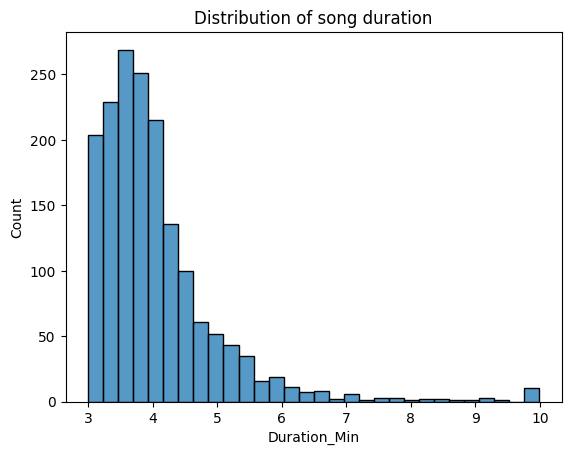

In [42]:
# Distribution of duration
g1 = sns.histplot(df['Duration_Min'], bins = 30)
g1.set_title('Distribution of song duration')


In [45]:
df['Duration_Min'].mode()

,Duration_Min
0,3.57


By looking at the histogram we can tell that majority of our songs have a duration between the range of 3 to 4 minutes, and the most number of songs, 250+ have a duration of 3.57

Text(0.5, 1.0, 'Songs per year')

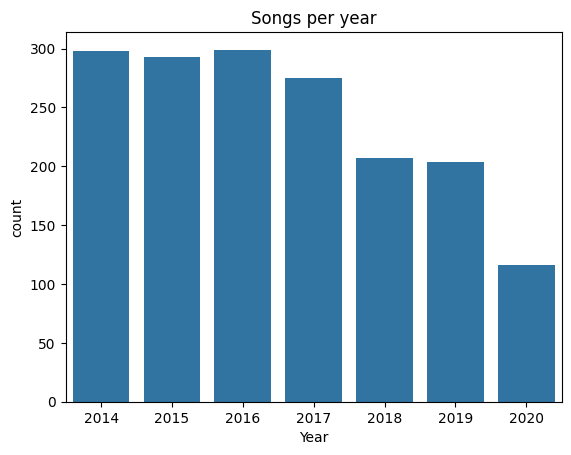

In [49]:
# track count per year
g2 = sns.barplot(df['Year'].value_counts().sort_index())
g2.set_title('Songs per year')



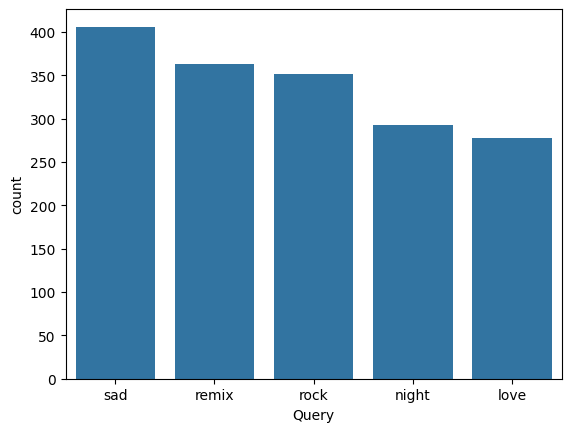

In [50]:
# song per theme
g3 = sns.barplot(df['Query'].value_counts())